EKSPLORASI CORPUS

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk

dataset = pd.read_csv("tripadvisor_hotel_reviews.csv")

dataset.head()


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Melihat 10 Data Pertama (Bagian E)

In [87]:
dataset.head(10)

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
5,love monaco staff husband stayed hotel crazy w...,5
6,"cozy stay rainy city, husband spent 7 nights m...",5
7,"excellent staff, housekeeping quality hotel ch...",4
8,"hotel stayed hotel monaco cruise, rooms genero...",5
9,excellent stayed hotel monaco past w/e delight...,5


Melihat 10 Data Terakhir (Bagian F)

In [88]:
dataset.tail(10)


,Review,Rating
20481,ok price look hotel ok little run average clea...,2
20482,great choice wife chose best western quite bit...,5
20483,good bed clean convenient just night happy sta...,4
20484,deceptive staff deceptive desk staff claiming ...,2
20485,not impressed unfriendly staff checked asked h...,2
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1
20490,"people talking, ca n't believe excellent ratin...",2


Informasi Kolom & Struktur Dataset (Bagian G, H, I, J)

In [89]:
print("--- Nama Kolom ---")
print(dataset.columns)
print("\n--- Informasi Dataset ---")
dataset.info()
print("\n--- Ukuran Dataset (Baris, Kolom) ---")
print(dataset.shape)
print("\n--- Jumlah Dokumen ---")
jumlah_dokumen = len(dataset)
print("Jumlah dokumen:", jumlah_dokumen)


--- Nama Kolom ---
Index(['Review', 'Rating'], dtype='str')

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  20491 non-null  str  
 1   Rating  20491 non-null  int64
dtypes: int64(1), str(1)
memory usage: 320.3 KB

--- Ukuran Dataset (Baris, Kolom) ---
(20491, 2)

--- Jumlah Dokumen ---
Jumlah dokumen: 20491


Memilih Kolom Teks (Bagian K & L)

In [90]:
text_column = "Review"
texts = dataset[text_column]

for text in texts.head(10):
    print(text)
    print("-" * 80)


nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
--------------------------------------------------------------------------------
ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites description kimpton website sorry 

Memeriksa Missing Value (Bagian M & N)

In [91]:
print("Missing Value Seluruh Kolom")
print(dataset.isnull().sum())   
print("\nMissing Value Kolom Teks ")
print(dataset[text_column].isnull().sum())

Missing Value Seluruh Kolom
Review    0
Rating    0
dtype: int64

Missing Value Kolom Teks 
0


Menghapus Data Kosong (Bagian O)

In [92]:
dataset = dataset.dropna(subset=[text_column])

print("Jumlah missing value setelah dihapus:")
print(dataset[text_column].isnull().sum())


Jumlah missing value setelah dihapus:
0


Memeriksa dan Menghapus Duplikasi Data (Bagian P & Q)

In [93]:
print("Duplikasi Seluruh Baris")
print(dataset.duplicated().sum())

print("\nDuplikasi Khusus Kolom Teks")
print(dataset[text_column].duplicated().sum())

dataset = dataset.drop_duplicates(subset=[text_column])


Duplikasi Seluruh Baris
0

Duplikasi Khusus Kolom Teks
0


Menghitung Jumlah Karakter & Jumlah Kata (Bagian R & S)

In [94]:
dataset["jumlah_karakter"] = dataset[text_column].astype(str).apply(len)

dataset["jumlah_kata"] = dataset[text_column].astype(str).apply(
    lambda x: len(x.split())
)

dataset[[text_column, "jumlah_karakter", "jumlah_kata"]].head()


,Review,jumlah_karakter,jumlah_kata
0,nice hotel expensive parking got good deal sta...,593,87
1,ok nothing special charge diamond member hilto...,1689,250
2,nice rooms not 4* experience hotel monaco seat...,1427,217
3,"unique, great stay, wonderful time hotel monac...",600,89
4,"great stay great stay, went seahawk game aweso...",1281,191


 Statistik Jumlah Kata (Bagian T)

In [95]:
dataset["jumlah_kata"].describe()


count    20491.000000
mean       104.375824
std        100.656586
min          7.000000
25%         48.000000
50%         77.000000
75%        124.000000
max       1931.000000
Name: jumlah_kata, dtype: float64

Setup NLTK Tokenizer (Bagian U)

In [96]:
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

text_uji = "Saya belajar NLP. NLP sangat menarik."
sentences = sent_tokenize(text_uji)
print("Hasil uji coba NLTK:")
print(sentences)


Hasil uji coba NLTK:
['Saya belajar NLP.', 'NLP sangat menarik.']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\labti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\labti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Menghitung Jumlah Kalimat dalam Dataset (Bagian V)

In [97]:
dataset["jumlah_kalimat"] = dataset[text_column].astype(str).apply(
    lambda x: len(sent_tokenize(x))
)


Melihat Statistik Keseluruhan Corpus (Bagian W)

In [98]:
print("Jumlah dokumen :", len(dataset))
print("Jumlah kata    :", dataset["jumlah_kata"].sum())
print("Jumlah kalimat :", dataset["jumlah_kalimat"].sum())
print("Jumlah karakter:", dataset["jumlah_karakter"].sum())


Jumlah dokumen : 20491
Jumlah kata    : 2138765
Jumlah kalimat : 20866
Jumlah karakter: 14853861


Visualisasi Distribusi Panjang Dokumen (Bagian X)

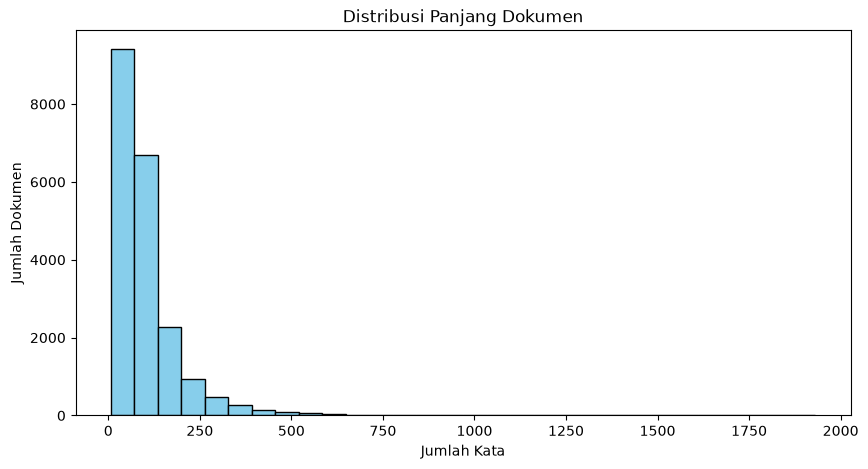

In [99]:
plt.figure(figsize=(10, 5))
plt.hist(dataset["jumlah_kata"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Dokumen")
plt.title("Distribusi Panjang Dokumen")
plt.show()


Distribusi Label Dataset (Bagian Y)

--- Distribusi Jumlah Label ---
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


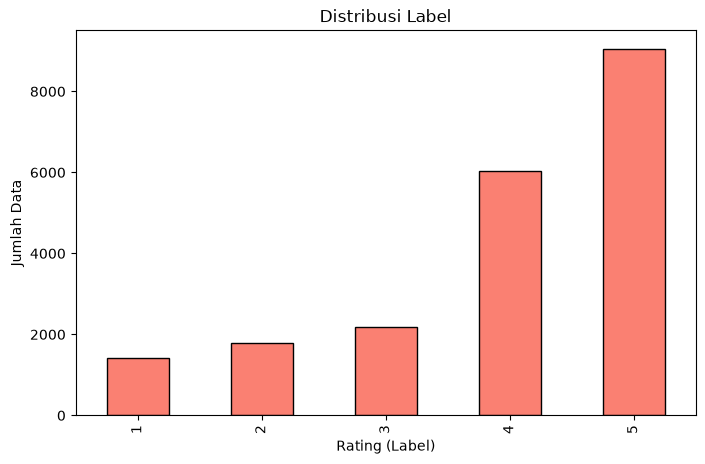

In [100]:
label_column = "Rating"

print("--- Distribusi Jumlah Label ---")
print(dataset[label_column].value_counts())

plt.figure(figsize=(8, 5))
dataset[label_column].value_counts().sort_index().plot(kind="bar", color='salmon', edgecolor='black')
plt.xlabel("Rating (Label)")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Label")
plt.show()
